In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# =========================================
# LSTM for Hourly Price Prediction
# =========================================

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# 1) Load & prepare data
# -------------------------

In [4]:
CSV_PATH = "/content/drive/MyDrive/ENGG680 Project Dataset/Table_Full Data_data 2.csv"
df = pd.read_csv(CSV_PATH, low_memory=False)

In [5]:
# Keep only what's needed (time + price)
df = df[["Date (MST)", "Price"]].copy()

In [6]:
# Parse datetime, sort, set index
df["Date (MST)"] = pd.to_datetime(df["Date (MST)"], errors="coerce")
df = df.dropna(subset=["Date (MST)", "Price"]).sort_values("Date (MST)").set_index("Date (MST)")

In [7]:
# Remove duplicate timestamps
df = df[~df.index.duplicated(keep="first")]

In [8]:
# Check missing values before interpolation (optional for report)
print("Missing Price values before cleaning:", df["Price"].isna().sum())

Missing Price values before cleaning: 0


In [10]:
# Resample to hourly in case of irregular spacing; interpolate missing values
df = df.resample("h").mean()
df["Price"] = df["Price"].interpolate(method="time").ffill().bfill()

In [11]:
# Double-check after interpolation
print("Missing Price values after cleaning:", df["Price"].isna().sum())

Missing Price values after cleaning: 0


# -------------------------
# 2) Train / test split
# -------------------------

In [12]:
SPLIT = 0.8  # last 20% for test
split_idx = int(len(df) * SPLIT)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

In [13]:
# Scale (fit on train only)
scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(train_df[["Price"]])
y_test = scaler_y.transform(test_df[["Price"]])

# -------------------------
# 3) Make supervised sequences
# -------------------------

In [14]:
LOOKBACK = 24 * 7  # 168 hours (one week history)

def make_sequences(series_2d, lookback):
    X, y = [], []
    for i in range(lookback, len(series_2d)):
        X.append(series_2d[i-lookback:i, :])
        y.append(series_2d[i, :])
    return np.array(X), np.array(y)

X_train, y_train_seq = make_sequences(y_train, LOOKBACK)
X_test,  y_test_seq  = make_sequences(y_test,  LOOKBACK)

print(f"Train sequences: X={X_train.shape}, y={y_train_seq.shape}")
print(f"Test  sequences: X={X_test.shape},  y={y_test_seq.shape}")

Train sequences: X=(37673, 168, 1), y=(37673, 1)
Test  sequences: X=(9293, 168, 1),  y=(9293, 1)


# -------------------------
# 4) Build & train model
# -------------------------

In [15]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    shuffle=False,           # Important for time series
    callbacks=[es],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0134 - val_loss: 0.0108
Epoch 2/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0055 - val_loss: 0.0073
Epoch 3/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0039 - val_loss: 0.0063
Epoch 4/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0035 - val_loss: 0.0062
Epoch 5/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0035 - val_loss: 0.0062
Epoch 6/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0035 - val_loss: 0.0062
Epoch 7/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0034 - val_loss: 0.0062
Epoch 8/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0034 - val_loss: 0.0062
Epoch 9/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0035 - val_loss: 0.0061
Epoch 10/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0034 - val_loss: 0.0061
Epoch 11/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0033 - val_loss: 0.0061
Epoch 12/50
471/471 ━━━━━━━━━━━━━━━━━━━━

# ============================
# Plot Train vs Validation Loss
# ============================

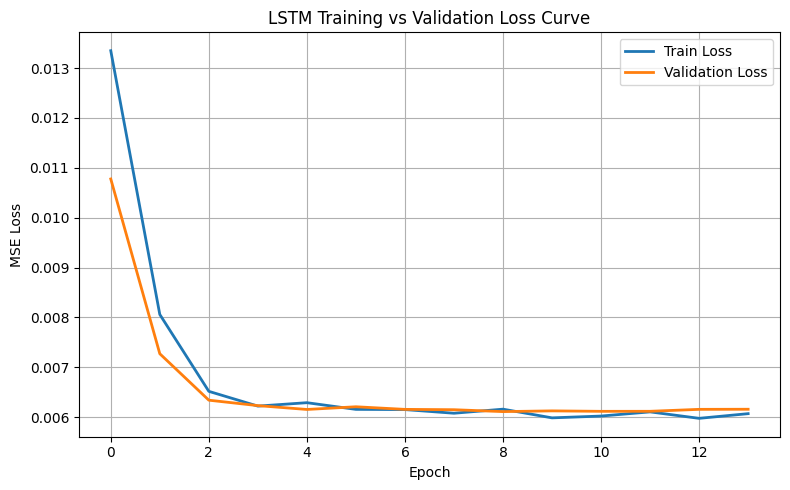

In [51]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# 5) Evaluate on test set
# -------------------------

In [18]:
y_pred_s = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_s).ravel()
y_true = scaler_y.inverse_transform(y_test_seq).ravel()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

smape = 100 * np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
)

r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"sMAPE: {smape:.2f}%")
print(f"R²: {r2:.3f}")

291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
MAE : 7.729
RMSE: 31.436
sMAPE: 21.81%
R²: 0.652


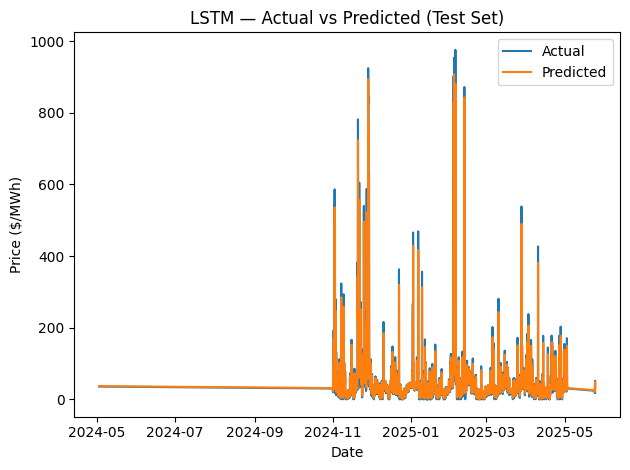

In [19]:
# Match with datetime index for plotting
test_index = test_df.index[LOOKBACK:] # align to y_test_seq
plot_df = pd.DataFrame({"Actual": y_true, "Predicted": y_pred}, index=test_index)

plt.figure()
plt.plot(plot_df.index, plot_df["Actual"], label="Actual")
plt.plot(plot_df.index, plot_df["Predicted"], label="Predicted")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("LSTM — Actual vs Predicted (Test Set)")
plt.legend(); plt.tight_layout(); plt.show()

# ============================
# Train vs Test Metrics Table
# ============================

In [54]:
# Predict on training sequences
y_train_pred_s = model.predict(X_train)
y_train_pred = scaler_y.inverse_transform(y_train_pred_s).ravel()

# True values must match the sequence-aligned labels
y_train_true = scaler_y.inverse_transform(y_train_seq).ravel()

# Compute metrics
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
train_smape = 100 * np.mean(
    2 * np.abs(y_train_pred - y_train_true) /
    (np.abs(y_train_true) + np.abs(y_train_pred) + 1e-8)
)
train_r2 = r2_score(y_train_true, y_train_pred)

print("=== Train vs Test Performance ===")
print(f"{'Metric':<10} {'Train':>15} {'Test':>15}")
print("-" * 45)
print(f"{'MAE':<10} {train_mae:15.3f} {mae:15.3f}")
print(f"{'RMSE':<10} {train_rmse:15.3f} {rmse:15.3f}")
print(f"{'sMAPE':<10} {train_smape:15.2f}% {smape:15.2f}%")
print(f"{'R²':<10} {train_r2:15.3f} {r2:15.3f}")


1178/1178 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
=== Train vs Test Performance ===
Metric               Train            Test
---------------------------------------------
MAE                 31.061           7.729
RMSE                76.271          31.436
sMAPE                20.43%           21.81%
R²                   0.782           0.652


# ============================
# Error Distribution Histogram
# ============================

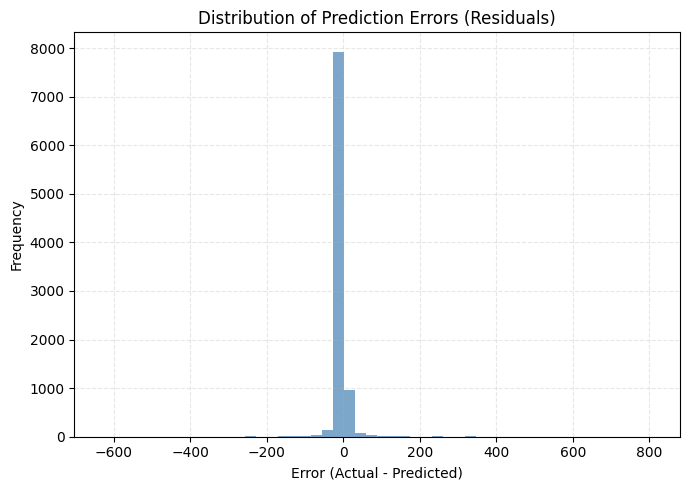

In [53]:
errors = y_true - y_pred  # test residuals

plt.figure(figsize=(7,5))
plt.hist(errors, bins=50, alpha=0.7, color="steelblue")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================
# Forecast next 24 hours (1 day)
# ==========================

In [31]:
FORECAST_HOURS = 24  # 24 hours ahead

# Use .values for consistent scaling
last_window = scaler_y.transform(df[["Price"]].iloc[-LOOKBACK:].values)
window = last_window.copy()
future_scaled = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, 1)
    next_scaled = model.predict(inp, verbose=0)[0, 0]
    future_scaled.append(next_scaled)

    # roll window
    window = np.vstack([window[1:], [[next_scaled]]])

# Inverse transform using proper feature name
future_scaled_df = pd.DataFrame(
    np.array(future_scaled).reshape(-1, 1),
    columns=["Price"]
)
future_prices = scaler_y.inverse_transform(future_scaled_df).ravel()

# Future index
future_index = pd.date_range(
    df.index[-1] + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq="h"
)

forecast_df = pd.DataFrame({"Forecast_Price": future_prices}, index=future_index)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


# -------------------------
# 6) Forecast next 168 hours
# -------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


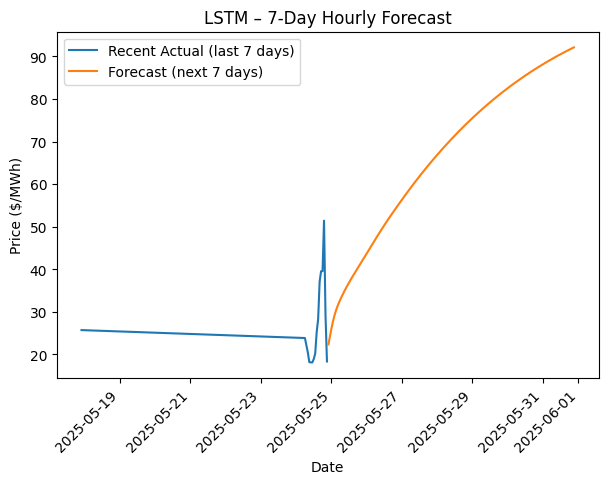

In [44]:
FORECAST_HOURS = 168  # 7 days ahead

last_window = scaler_y.transform(df[["Price"]].iloc[-LOOKBACK:].values)
window = last_window.copy()
future_scaled = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, 1)
    next_scaled = model.predict(inp, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
    # roll window
    window = np.vstack([window[1:], [[next_scaled]]])

future_prices = scaler_y.inverse_transform(np.array(future_scaled).reshape(-1, 1)).ravel()

future_index = pd.date_range(df.index[-1] + pd.Timedelta(hours=1),
                             periods=FORECAST_HOURS, freq="h")
forecast_df = pd.DataFrame({"Forecast_Price": future_prices}, index=future_index)

plt.figure()
plt.plot(df.index[-7*24:], df["Price"].iloc[-7*24:], label="Recent Actual (last 7 days)")
plt.plot(forecast_df.index, forecast_df["Forecast_Price"], label="Forecast (next 7 days)")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("LSTM – 7-Day Hourly Forecast")
plt.legend(); plt.tight_layout();
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45, ha='right')
plt.show()

# ==========================
# PART 7: Seasonal Comparison (Summer vs Winter)
# ==========================

Columns: Index(['Date - MST', 'Hourly Profile1', 'Season1', 'Date (MST)', 'AIL',
       'Gas Price', 'Price', 'Spark Spread'],
      dtype='object')


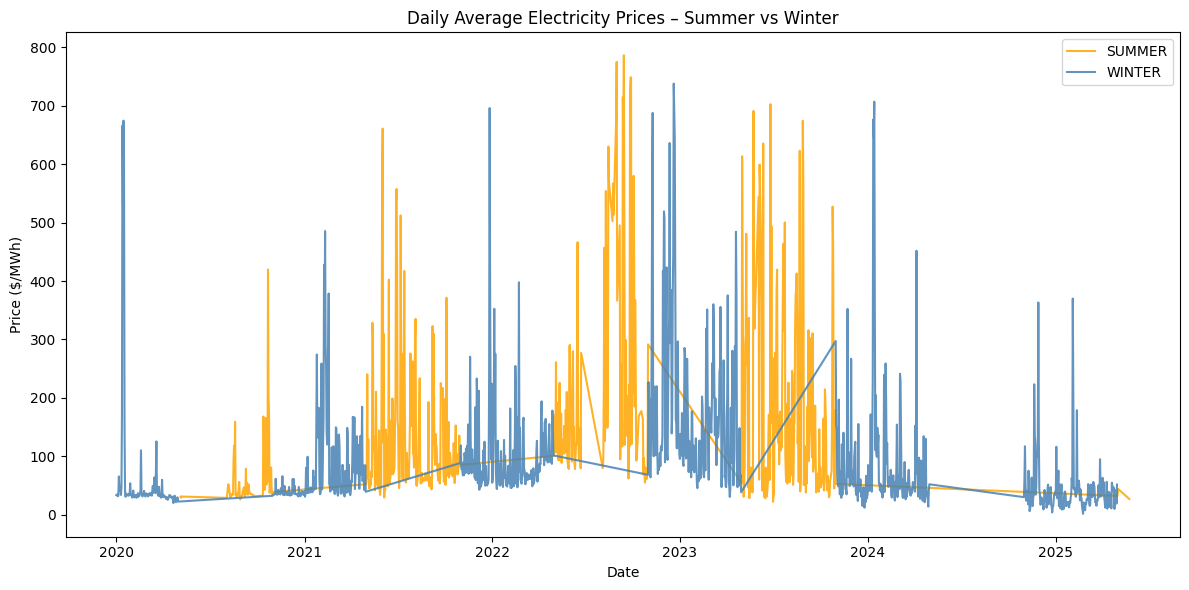

In [50]:
# ============================================
# PART 7 — Seasonal Comparison (Summer vs Winter)
# ============================================

orig = pd.read_csv("/content/drive/MyDrive/ENGG680 Project Dataset/Table_Full Data_data 2.csv")

# Parse datetime correctly
orig["ParsedDate"] = pd.to_datetime(orig["Date (MST)"], errors="coerce")

# Drop rows where date could not be parsed
orig = orig.dropna(subset=["ParsedDate"])

# Set ParsedDate as index
orig = orig.set_index("ParsedDate")
orig = orig.sort_index()

print("Columns:", orig.columns)

# --- Compute daily price averages with Season1 ---
daily = (
    orig.groupby([orig.index.normalize(), orig["Season1"]])["Price"]
        .mean()
        .reset_index()
)

# Rename the first column to a proper datetime name
daily = daily.rename(columns={"ParsedDate": "Date", 0: "Date"})
daily["Date"] = pd.to_datetime(daily["Date"])

# --- Plot ---
plt.figure(figsize=(12, 6))

for season, color in zip(["SUMMER", "WINTER"], ["orange", "steelblue"]):
    subset = daily[daily["Season1"] == season]
    plt.plot(subset["Date"], subset["Price"], label=season, color=color, alpha=0.85)

plt.title("Daily Average Electricity Prices – Summer vs Winter")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.legend()
plt.tight_layout()
plt.show()
